In [ ]:
import pandas as pd
import io
import re


In [ ]:

# 1. Carrega o arquivo corrompido como texto puro
with open(
    '/content/feedback_clientes_piston.csv', 'r', encoding='utf-8'
) as file:
  conteudo = file.read()

# 2. Remove todos os padrões '' do arquivo
conteudo_limpo = re.sub(r'\\s*', '', conteudo)

# 3. Corrige as quebras de linhas órfãs (como o "Irritante!")
linhas = conteudo_limpo.splitlines()
linhas_corrigidas = []

for linha in linhas:
  linha = linha.strip()
  if not linha:
    continue
  # Se a linha não começa com TKT- ou com o cabeçalho, ela é a continuação da descrição anterior
  if not (linha.startswith('TKT-') or linha.startswith('ID_Ticket')):
    if linhas_corrigidas:
      linhas_corrigidas[-1] = linhas_corrigidas[-1] + ' ' + linha
  else:
    linhas_corrigidas.append(linha)

# 4. Trata as vírgulas internas das descrições para o Pandas não se perder
linhas_finais = []
for linha in linhas_corrigidas:
  if linha.startswith('ID_Ticket'):
    linhas_finais.append(linha)
    continue

  # Divide a linha apenas nas primeiras 6 vírgulas encontradas
  partes = linha.split(',', 6)
  if len(partes) == 7:
    # Envolve a descrição (7ª parte) em aspas duplas
    partes[6] = f'"{partes[6]}"'
    linhas_finais.append(','.join(partes))

# 5. Cria o DataFrame a partir do texto corrigido
csv_final = '\n'.join(linhas_finais)
df_clientes_piston = pd.read_csv(io.StringIO(csv_final))

# Exibe o DataFrame pronto para análise
df_clientes_piston

,ID_Ticket,Data,Regiao,Modelo_Carro,Categoria_Problema,Nota_Satisfacao,Descricao_Cliente
0,TKT-001,2026-05-10,Sudeste,X-Sedan,Desempenho do Motor,2,O carro perde força em subidas íngremes.
1,TKT-002,2026-05-11,Sul,X-SUV,Sistema de Entretenimento,1,A tela multimídia desliga sozinha após 20 minu...
2,TKT-003,2026-05-12,Nordeste,X-Hatch,Design do Interior,4,"Os bancos são confortáveis, mas o painel refle..."
3,TKT-004,2026-05-12,Sudeste,X-SUV,Sistema de Entretenimento,2,O bluetooth desconecta o tempo todo. Irritante!
4,TKT-005,2026-05-14,Centro-Oeste,X-Sedan,Desempenho do Motor,1,Sinto solavancos ao trocar de marcha em alta v...
5,TKT-006,2026-05-15,Sul,X-Hatch,Segurança,5,Os freios ABS responderam perfeitamente na chuva.
6,TKT-007,2026-05-15,Sudeste,X-SUV,Sistema de Entretenimento,1,GPS nativo travou e a tela ficou preta no meio...
7,TKT-008,2026-05-16,Nordeste,X-SUV,Desempenho do Motor,4,"Motor silencioso, consumo ok."
8,TKT-009,2026-05-18,Sudeste,X-Sedan,Desempenho do Motor,2,Luz de injeção acendeu com apenas 5.000 km rod...
9,TKT-010,2026-05-19,Norte,X-SUV,Sistema de Entretenimento,1,Não consigo emparelhar o celular de jeito nenhum.


<Figure size 1200x600 with 0 Axes>

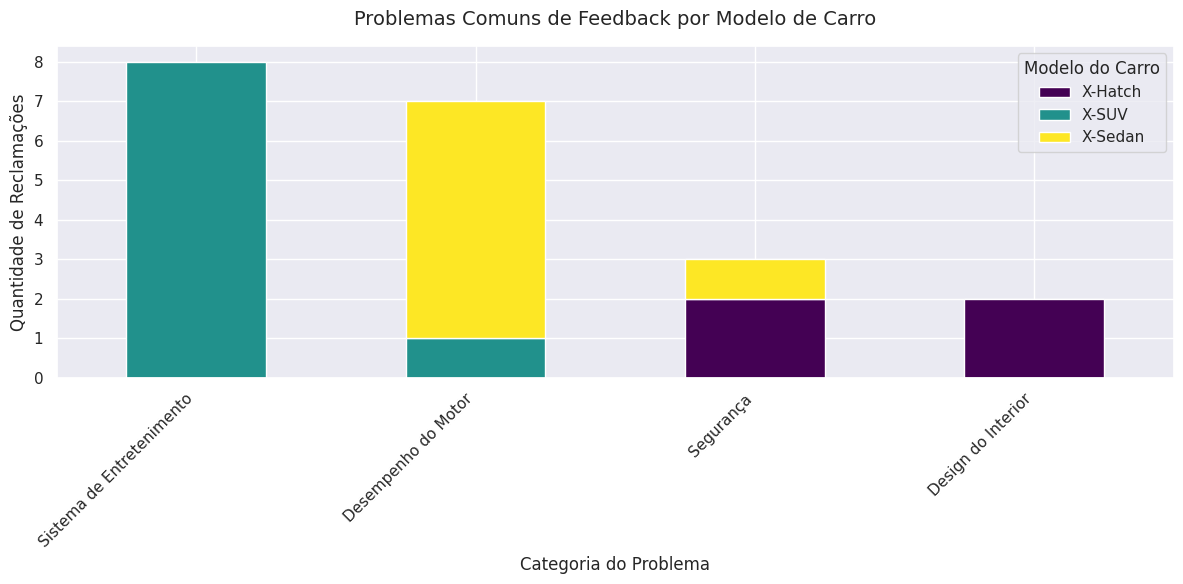

--- Média de Satisfação por Categoria de Problema ---
Categoria_Problema
Sistema de Entretenimento    1.375000
Desempenho do Motor          1.857143
Design do Interior           3.500000
Segurança                    4.666667
Name: Nota_Satisfacao, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurando o estilo dos gráficos
sns.set_theme(style='darkgrid')
plt.figure(figsize=(12, 6))

# 1. Criando o gráfico de barras agrupando Categoria do Problema e Modelo do Carro
# Contando a quantidade de reclamações (IDs dos tickets)
df_agrupado = (
    df_clientes_piston.groupby(['Categoria_Problema', 'Modelo_Carro'])
    .size()
    .unstack(fill_value=0)
)

# Ordenando o gráfico pelos problemas mais frequentes no total
df_agrupado['Total'] = df_agrupado.sum(axis=1)
df_agrupado = df_agrupado.sort_values(by='Total', ascending=False).drop(
    columns='Total'
)

# Plotando as barras empilhadas
df_agrupado.plot(kind='bar', stacked=True, figsize=(12, 6), cmap='viridis')

plt.title('Problemas Comuns de Feedback por Modelo de Carro', fontsize=14, pad=15)
plt.xlabel('Categoria do Problema', fontsize=12)
plt.ylabel('Quantidade de Reclamações', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.legend(title='Modelo do Carro')
plt.tight_layout()
plt.show()

# 2. Análise complementar: Média da Nota de Satisfação por Categoria
print('--- Média de Satisfação por Categoria de Problema ---')
print(
    df_clientes_piston.groupby('Categoria_Problema')['Nota_Satisfacao']
    .mean()
    .sort_values()
)

/tmp/ipykernel_3339/1670712481.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


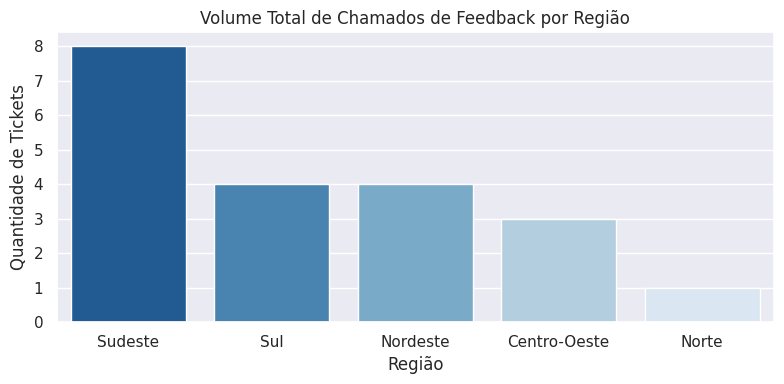

In [ ]:

plt.figure(figsize=(8, 4))
regiao_counts = df_clientes_piston['Regiao'].value_counts()

sns.barplot(
    x=regiao_counts.index, y=regiao_counts.values, palette='Blues_r'
)

plt.title('Volume Total de Chamados de Feedback por Região')
plt.xlabel('Região')
plt.ylabel('Quantidade de Tickets')
plt.tight_layout()
plt.show()